# BioSample trace-back analysis

This notebook examines how curated BioSample field values are represented in the original raw metadata: how many raw field names contribute evidence to each target field, how concentrated that evidence is, how much comes from structured fields versus free text, and how these patterns vary across the dataset and over time. For how the matching cascade itself works and what each tier means, individual matching errors, and the LLM evidence tier's precision/recall against a reviewed ground truth, see `biosample_trace_back_evaluation.ipynb`.

In [1]:
# TABLE OF CONTENTS
import sys

sys.path.insert(0, "../src")
from notebook_utils import table_of_contents

table_of_contents("biosample_trace_back_analysis.ipynb")

### Table of contents


[BioSample trace-back analysis](#BioSample-trace-back-analysis)
- [Setup](#Setup)
- [Raw-field diversity](#Raw-field-diversity)
  - [Evidence concentration](#Evidence-concentration)
  - [How concentrated is that evidence, exactly?](#How-concentrated-is-that-evidence,-exactly?)
  - [How many raw fields does it take to reach a given % of coverage?](#How-many-raw-fields-does-it-take-to-reach-a-given-%-of-coverage?)
- [Where the evidence comes from: the target field itself, another structured field, or free text](#Where-the-evidence-comes-from:-the-target-field-itself,-another-structured-field,-or-free-text)
- [Why isn't every record linked to a BioProject?](#Why-isn't-every-record-linked-to-a-BioProject?)
- [How does raw-field-name diversity vary by year?](#How-does-raw-field-name-diversity-vary-by-year?)
  - [What does the raw (non-rarefied) growth curve look like?](#What-does-the-raw-(non-rarefied)-growth-curve-look-like?)
  - [What were the top field names unique to each year?](#What-were-the-top-field-names-unique-to-each-year?)
- [Summary](#Summary)

## Setup

In [2]:
# IMPORTS
import html

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from field_diversity import (
    concentration_curve,
    explode_raw_fields,
    is_free_text_field,
    normalize_field_name,
    rarefied_unique_counts,
)
from notebook_utils import RawHTML, display_with_nested_tables, md
from paths import BIOSAMPLE_METADATA_PARQUET, TRACE_BACK_FULL_PARQUET

In [3]:
# LOAD AND JOIN: trace-back rows, per-accession metadata, exploded to one row per evidence field
trace_back = pd.read_parquet(TRACE_BACK_FULL_PARQUET)

metadata = pd.read_parquet(BIOSAMPLE_METADATA_PARQUET).drop_duplicates("accession")
metadata["year_submission"] = pd.to_datetime(metadata["submission_date"], format="mixed", utc=True, errors="coerce").dt.year
metadata["year_publication"] = pd.to_datetime(metadata["publication_date"], format="mixed", utc=True, errors="coerce").dt.year

exploded = explode_raw_fields(trace_back).merge(
    metadata[["accession", "bioproject_id", "owner", "year_submission", "year_publication"]], on="accession", how="left"
)
exploded["raw_field_norm"] = exploded["raw_field"].map(normalize_field_name)
exploded["is_free_text"] = exploded["raw_field"].map(is_free_text_field)

TARGET_FIELDS = sorted(trace_back["target_field"].unique())

md(f"Loaded **{len(trace_back):,}** trace-back rows across **{trace_back['accession'].nunique():,}** accessions, **{trace_back['run_name'].nunique()}** runs; **{len(exploded):,}** (value, evidence field) pairs after exploding the found ones.")

Loaded **8,194,813** trace-back rows across **3,989,387** accessions, **311** runs; **8,618,975** (value, evidence field) pairs after exploding the found ones.

In [4]:
# FIXED CATEGORICAL PALETTE FOR THE 9 TARGET FIELDS (Okabe-Ito, colorblind-safe, fixed order)
TARGET_FIELD_COLORS = dict(
    zip(TARGET_FIELDS, ["#E69F00", "#56B4E9", "#009E73", "#F0E442", "#0072B2", "#D55E00", "#CC79A7", "#999999", "#000000"])
)

In [5]:
# YEAR RANGE AND RAREFACTION SETTINGS, SHARED BY EVERY YEAR-TREND ANALYSIS BELOW
YEAR_RANGE = (2012, 2025)  # earlier years too sparse for a stable rarefied estimate; 2026 only partially elapsed
N_RAREFACTION_ITER = 10

## Raw-field diversity

The analysis below compares the number of distinct raw field names with the number remaining after simple normalization. It then shows which fields carry most of the evidence and how much of the evidence is concentrated in a small set of names.

In [6]:
# UNIQUE RAW FIELD NAMES PER TARGET FIELD, RAW VS. REGEX-NORMALIZED
def field_diversity_table(exploded: pd.DataFrame) -> pd.DataFrame:
    table = pd.DataFrame(
        {
            "n_unique_raw_field": exploded.groupby("target_field")["raw_field"].nunique(),
            "n_unique_normalized": exploded.groupby("target_field")["raw_field_norm"].nunique(),
        }
    )
    table["pct_reduction"] = 100 * (1 - table["n_unique_normalized"] / table["n_unique_raw_field"])
    return table.sort_values("n_unique_raw_field", ascending=False)


diversity_table = field_diversity_table(exploded)
diversity_table.style.format({"n_unique_raw_field": "{:,}", "n_unique_normalized": "{:,}", "pct_reduction": "{:.1f}%"})

,n_unique_raw_field,n_unique_normalized,pct_reduction
target_field,,,
overexpressed_gene,"1,717","1,648",4.0%
knockout_gene,"1,658","1,577",4.9%
cell_line,"1,477","1,369",7.3%
drug,"1,465","1,369",6.6%
chip_antigen,"1,356","1,277",5.8%
knockdown_gene,"1,183","1,133",4.2%
tissue,"1,050",962,8.4%
disease,947,877,7.4%
cell_type,843,760,9.8%


In [7]:
# POOLED ACROSS ALL 9 TARGET FIELDS
n_pooled_raw = exploded["raw_field"].nunique()
n_pooled_norm = exploded["raw_field_norm"].nunique()
md(
    f"Pooled across all target fields, there are **{n_pooled_raw:,}** distinct raw field name strings, "
    f"reduced to **{n_pooled_norm:,}** ({100 * (1 - n_pooled_norm / n_pooled_raw):.1f}% fewer) after normalization -- "
    "a real but modest reduction: most of the diversity is genuinely different field names, not just spelling/case/separator variants of the same one."
)

Pooled across all target fields, there are **6,113** distinct raw field name strings, reduced to **5,624** (8.0% fewer) after normalization -- a real but modest reduction: most of the diversity is genuinely different field names, not just spelling/case/separator variants of the same one.

### Evidence concentration

These views show which raw field names contribute most of the evidence for each curated field, and how many names are needed to cover most of it.

In [8]:
# TOP RAW FIELDS PER TARGET FIELD, BY % SHARE OF THAT FIELD'S MATCHED EVIDENCE
def top_raw_fields_per_target(exploded: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    rows = []
    for target_field in TARGET_FIELDS:
        counts = exploded.loc[exploded["target_field"] == target_field, "raw_field"].value_counts()
        total_n = counts.sum()
        top = counts.head(top_n)
        parts = [f"<b>{html.escape(field)}</b> ({100 * n / total_n:.0f}%)" for field, n in top.items()]
        n_other_fields = len(counts) - len(top)
        if n_other_fields > 0:
            parts.append(f"<b>other</b> ({n_other_fields:,} fields, {100 * (total_n - top.sum()) / total_n:.0f}%)")
        rows.append({"target_field": target_field, "total_n": total_n, "top_raw_fields": RawHTML(", ".join(parts))})
    return pd.DataFrame(rows).sort_values("total_n", ascending=False)


top_fields = top_raw_fields_per_target(exploded)
display_with_nested_tables(top_fields.assign(total_n=top_fields["total_n"].map("{:,}".format)))

target_field,total_n,top_raw_fields
tissue,"2,951,013","tissue (58%), source_name (13%), organism part (7%), body site (7%), cell type (3%), histological type (1%), biospecimen repository sample id (1%), submitted sample id (1%), disease (1%), isolate (1%), cell_type (0%), sample type (0%), study name (0%), comment (0%), tissue type (0%), title (0%), brain region (0%), cell line (0%), organ (0%), tissue_type (0%), other (1,030 fields, 5%)"
cell_type,"1,893,717","cell type (68%), source_name (7%), cell_type (7%), tissue (4%), histological type (2%), celltype (1%), cell line (1%), title (1%), inferred cell type (1%), comment (1%), cell cluster (0%), tissue/cell type (0%), isolate (0%), cell (0%), tissue/celltype (0%), ArrayExpress-CellType (0%), inferred_cell_type (0%), treatment (0%), developmental stage (0%), ArrayExpress-CELL_TYPE (0%), other (823 fields, 5%)"
cell_line,"1,067,650","cell line (52%), cell_line (23%), source_name (5%), cell type (4%), tissue (2%), isolate (2%), title (1%), biomaterial_provider (1%), Submitter Id (1%), treatment (1%), growth condition (1%), cell_type (1%), strain (1%), comment (0%), histological type (0%), cell (0%), genotype (0%), body site (0%), stimulus (0%), Ids.Id (0%), other (1,457 fields, 4%)"
drug,"922,885","treatment (54%), comment (13%), chemical_name (12%), title (2%), agent (1%), Compound (1%), sample_name (1%), stimulus (1%), chemical name (1%), study name (1%), Submitter Id (1%), source_name (1%), isolate (1%), drug treatment (0%), chemical (0%), drug (0%), treatments (0%), condition (0%), group (0%), stimulation (0%), other (1,445 fields, 9%)"
disease,"658,006","disease (24%), disease state (9%), study disease (9%), source_name (8%), tissue (7%), study name (7%), cell type (7%), diagnosis (3%), isolate (1%), histological type (1%), diseaseseverity (1%), title (1%), condition (1%), cell line (1%), health state (1%), patient diagnosis (1%), diabetes (1%), subject status (1%), treatment (1%), health_state (1%), other (927 fields, 15%)"
knockout_gene,"439,305","genotype (51%), comment (7%), title (6%), strain (6%), genotype/variation (5%), treatment (3%), source_name (2%), cell line (1%), Submitter Id (1%), cell type (1%), Ids.Id (1%), isolate (1%), sample_name (0%), group (0%), phenotype (0%), full_genotype (0%), sample description (0%), condition (0%), sample (0%), RefGroup (0%), other (1,638 fields, 11%)"
chip_antigen,"375,619","comment (35%), chip antibody (23%), antibody (9%), title (6%), phenotype (5%), facs marker (3%), immunophenotype (2%), genotype (1%), treatment (1%), cell type (1%), source_name (1%), Submitter Id (1%), target (1%), chip-antibody (1%), antibody antibodydescription (0%), antibodies (0%), sample_name (0%), ChIP (0%), Ids.Id (0%), genotype/variation (0%), other (1,336 fields, 10%)"
overexpressed_gene,"221,522","genotype (27%), treatment (9%), strain (9%), title (6%), comment (6%), genotype/variation (6%), source_name (3%), cell type (3%), cell line (2%), transgene (1%), induction (1%), phenotype (1%), transduction (1%), transfection (1%), tissue (1%), Submitter Id (1%), sample_name (1%), isolate (1%), expression (0%), condition (0%), other (1,697 fields, 21%)"
knockdown_gene,"89,258","treatment (20%), genotype (19%), title (10%), comment (5%), genotype/variation (4%), sirna (4%), shRNA (3%), source_name (2%), knockdown (2%), Submitter Id (2%), isolate (1%), transfection (1%), Ids.Id (1%), condition (1%), sample_name (1%), cell type (1%), transduction (1%), shRNA geneid (1%), cell line (1%), Links.Link (1%), other (1,163 fields, 22%)"


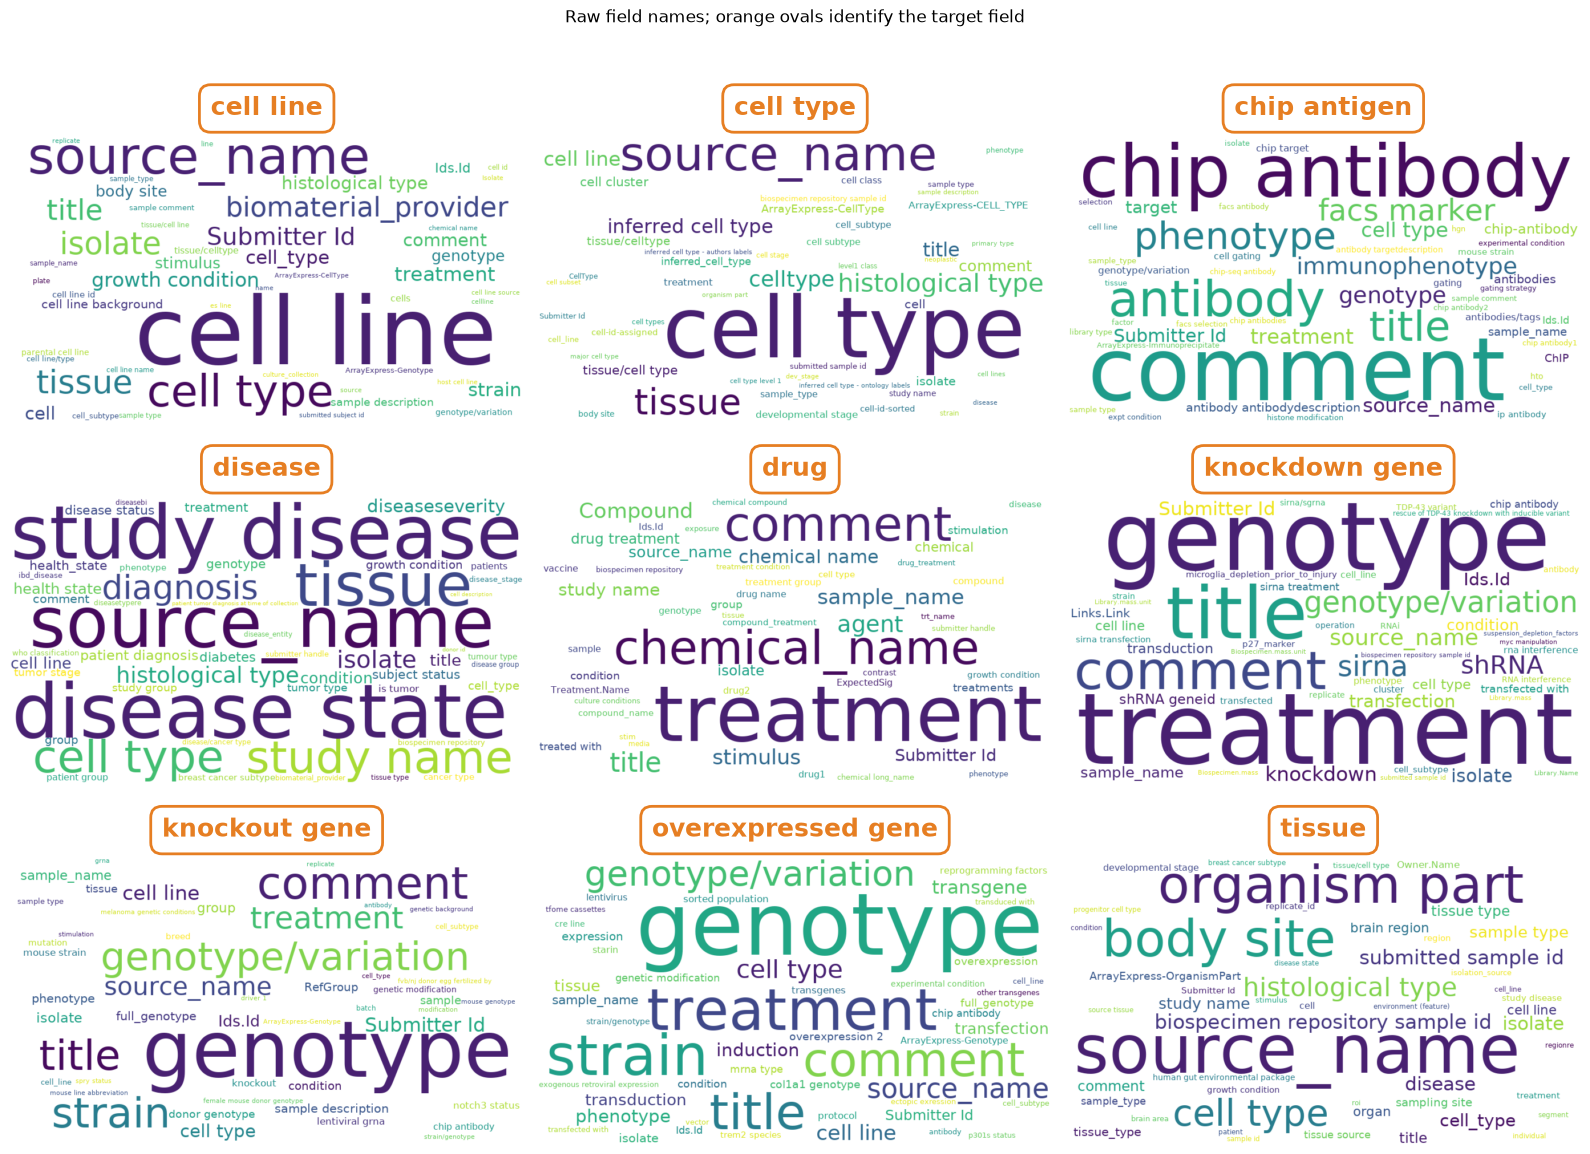

In [9]:
# TAG CLOUDS: RAW FIELD NAMES WITH WRAPPED OVAL TARGET TITLES
import textwrap

from matplotlib.font_manager import findfont
from wordcloud import WordCloud

TAG_CLOUD_FONT = findfont("DejaVu Sans")


def plot_raw_field_tag_clouds(
    exploded: pd.DataFrame,
    max_words: int = 50,
    figsize: tuple[float, float] = (16, 12),
) -> None:
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    axes = axes.ravel()

    for axis, target_field in zip(axes, TARGET_FIELDS):
        counts = exploded.loc[
            (exploded["target_field"] == target_field) & (exploded["raw_field"] != target_field),
            "raw_field",
        ].value_counts().head(max_words)
        cloud = WordCloud(
            width=900,
            height=500,
            max_words=max_words,
            font_path=TAG_CLOUD_FONT,
            background_color="white",
            colormap="viridis",
            collocations=False,
            prefer_horizontal=1.0,
            random_state=42,
        ).generate_from_frequencies(counts.to_dict())
        axis.imshow(cloud, interpolation="bilinear")
        axis.set_title(
            textwrap.fill(target_field.replace("_", " "), width=24),
            fontsize=18,
            fontweight="bold",
            color="#e67e22",
            pad=16,
            bbox={"boxstyle": "round,pad=0.45", "facecolor": "white", "edgecolor": "#e67e22", "linewidth": 2},
        )
        axis.axis("off")

    for axis in axes[len(TARGET_FIELDS) :]:
        axis.axis("off")
    fig.suptitle("Raw field names; orange ovals identify the target field", y=0.995)
    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.show()


plot_raw_field_tag_clouds(exploded)

### How concentrated is that evidence, exactly?

The table above hides how "concentrated" each field's evidence really is, since `other` lumps everything past the top 20 into one number. The two charts below show this from both sides, for the same 9 target fields, side by side. The left chart is about evidence VOLUME: how much of a field's matched evidence the single top raw field covers alone, how much the next 4 add (fields 2-5), the next 15 (fields 6-20), the next 80 (fields 21-100), and finally everything beyond the top 100 -- the segments always sum to 100%. A bar that's almost entirely dark means a handful of names carry the field; a bar with a long light tail means the evidence really is scattered across hundreds of differently-named fields. The right chart is about the field VOCABULARY itself: how many distinct raw field names are needed to reach 90% of a field's evidence, how many more names are used more than once without being needed for that 90%, and how many are singletons -- a raw field name that shows up in evidence for exactly one BioSample record (not one BioProject: the same name can still repeat across many samples within a single BioProject and count as a singleton here, since this counts BioSample-level evidence rows, not distinct projects).

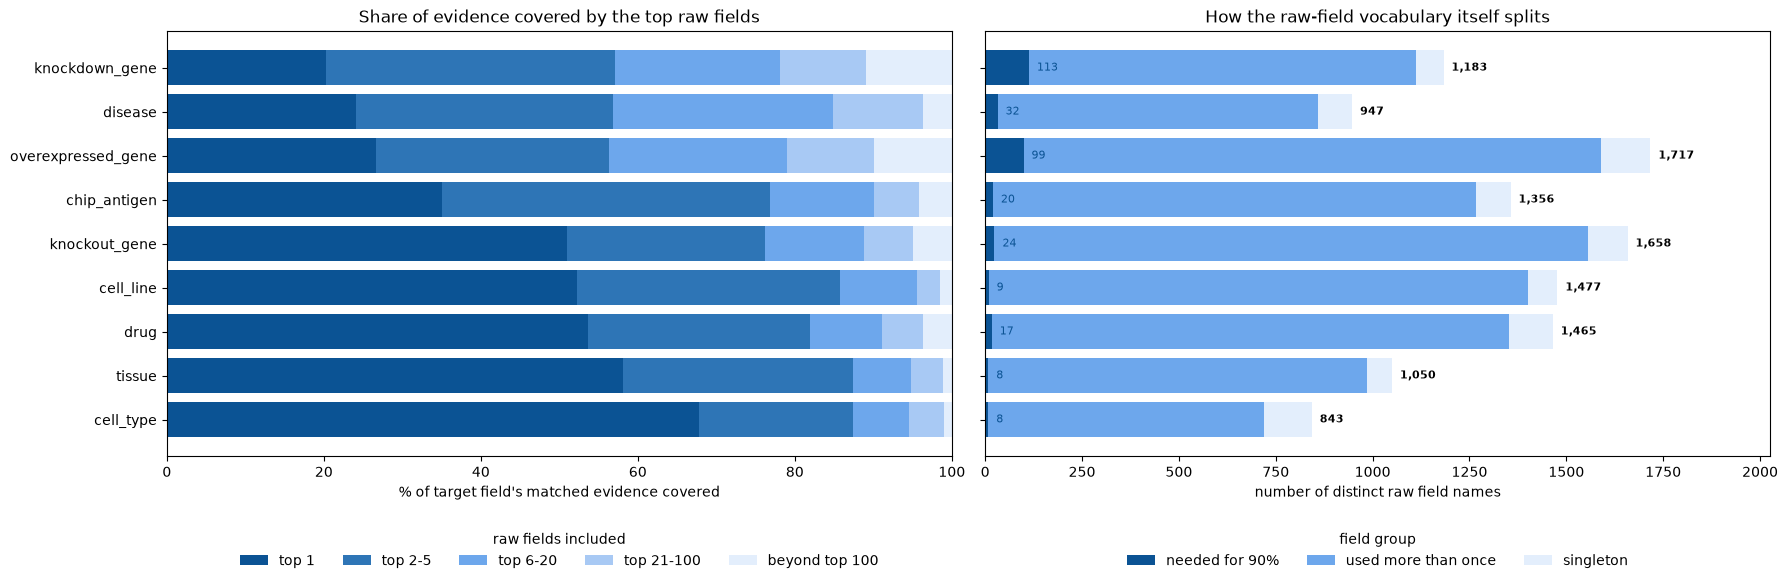

In [10]:
# EVIDENCE CONCENTRATION, TWO VIEWS SIDE BY SIDE: SHARE OF EVIDENCE VS. SIZE OF THE FIELD VOCABULARY
def concentration_by_threshold_segments(
    exploded: pd.DataFrame, thresholds: tuple[int, ...] = (1, 5, 20, 100)
) -> tuple[pd.DataFrame, list[str]]:
    rows = []
    for target_field in TARGET_FIELDS:
        counts = exploded.loc[exploded["target_field"] == target_field, "raw_field"].value_counts()
        curve = concentration_curve(counts)
        cum = {t: curve.loc[curve["n_fields"] == min(t, len(curve)), "pct_covered"].iloc[0] for t in thresholds}
        rows.append({"target_field": target_field, **cum})
    table = pd.DataFrame(rows).set_index("target_field").sort_values(thresholds[0], ascending=False)

    # cumulative coverage per threshold -> incremental segments, so the stacked bar sums to 100%
    segment_labels = [f"top {thresholds[0]}"]
    segment_labels += [f"top {thresholds[i - 1] + 1}-{thresholds[i]}" for i in range(1, len(thresholds))]
    segment_labels += [f"beyond top {thresholds[-1]}"]

    segments = pd.DataFrame(index=table.index)
    segments[segment_labels[0]] = table[thresholds[0]]
    for i in range(1, len(thresholds)):
        segments[segment_labels[i]] = table[thresholds[i]] - table[thresholds[i - 1]]
    segments[segment_labels[-1]] = 100 - table[thresholds[-1]]
    return segments, segment_labels


def concentration_segments_by(
    exploded: pd.DataFrame, group_col: str, groups: list, threshold: float = 90.0
) -> tuple[pd.DataFrame, list[str]]:
    """Splits the raw-field VOCABULARY (a count of distinct names, not evidence volume) seen
    within each value of `group_col` into three non-overlapping groups: the top names needed to
    reach `threshold`% of that group's evidence, the rest of the names used more than once, and
    singletons (see the markdown above for exactly what "singleton" counts). `group_col` is
    typically `target_field` (vocabulary per curated field) or a year column (vocabulary per
    calendar year, pooled across target fields).
    """
    rows = []
    for group in groups:
        counts = exploded.loc[exploded[group_col] == group, "raw_field"].value_counts()
        curve = concentration_curve(counts)
        n_for_threshold = int(curve.loc[curve["pct_covered"] >= threshold, "n_fields"].min())
        n_used_more_than_once = int((counts > 1).sum())
        n_singleton = int((counts == 1).sum())
        n_for_threshold = min(n_for_threshold, n_used_more_than_once)  # guards a fully flat group where even the top names are singletons
        rows.append(
            {
                group_col: group,
                f"needed for {int(threshold)}%": n_for_threshold,
                "used more than once": n_used_more_than_once - n_for_threshold,
                "singleton": n_singleton,
            }
        )
    segments = pd.DataFrame(rows).set_index(group_col)
    return segments, list(segments.columns)


def field_count_segments(exploded: pd.DataFrame, threshold: float = 90.0) -> tuple[pd.DataFrame, list[str]]:
    """`concentration_segments_by` grouped by target field -- see that function's docstring."""
    return concentration_segments_by(exploded, "target_field", TARGET_FIELDS, threshold)


def plot_evidence_concentration(exploded: pd.DataFrame, figsize: tuple[float, float] = (18, 6)) -> None:
    threshold_segments, threshold_labels = concentration_by_threshold_segments(exploded)
    field_segments, field_labels = field_count_segments(exploded)
    order = threshold_segments.index  # both panels share the same target-field order (by top-1 concentration)
    field_segments = field_segments.loc[order]

    threshold_colors = ["#0b5394", "#2e75b6", "#6da7ec", "#a8c9f4", "#e3eefc"][: len(threshold_labels)]
    field_colors = ["#0b5394", "#6da7ec", "#e3eefc"]  # same blue family as the left panel, light = long tail in both

    fig, (ax_pct, ax_count) = plt.subplots(1, 2, figsize=figsize, sharey=True)
    y_pos = range(len(order))
    for ax, segments, labels, colors, xlabel, title, legend_title in [
        (ax_pct, threshold_segments, threshold_labels, threshold_colors, "% of target field's matched evidence covered", "Share of evidence covered by the top raw fields", "raw fields included"),
        (ax_count, field_segments, field_labels, field_colors, "number of distinct raw field names", "How the raw-field vocabulary itself splits", "field group"),
    ]:
        left = pd.Series(0.0, index=segments.index)
        for label, color in zip(labels, colors):
            ax.barh(y_pos, segments[label], left=left, label=label, color=color)
            left += segments[label]
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels(order)
        ax.set_xlabel(xlabel)
        ax.set_title(title)
        ax.legend(title=legend_title, loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=len(labels), frameon=False)
    ax_pct.set_xlim(0, 100)

    # exact counts on the vocabulary-split panel: end of the "needed for 90%" segment, and the bar's total
    need_for_90 = field_segments[field_labels[0]]
    totals = field_segments.sum(axis=1)
    ax_count.set_xlim(0, totals.max() * 1.18)
    for y, target_field in zip(y_pos, order):
        ax_count.text(need_for_90[target_field], y, f"  {int(need_for_90[target_field]):,}", va="center", ha="left", fontsize=8, color=field_colors[0])
        ax_count.text(totals[target_field], y, f"  {int(totals[target_field]):,}", va="center", ha="left", fontsize=8, color="black", fontweight="bold")

    plt.tight_layout()
    plt.show()


plot_evidence_concentration(exploded)

Fields like `cell_type`/`tissue`/`cell_line` are dominated by a small handful of raw field names -- most of the "8,000+ different fields" problem for these is a long tail that barely matters in volume.
Fields like `disease`/`knockout_gene`/`overexpressed_gene`/`knockdown_gene` need many more distinct raw fields to cover the same share of evidence -- their information really is scattered across a wider variety of submitter-chosen field names, which is exactly the harder case an LLM-based approach is for.

A large share of each target field's raw-field vocabulary is used exactly once, but those singletons account for a negligible share of actual evidence -- confirming that the "8,000+ fields" figure is dominated by rarely-used, idiosyncratic names, and that the LLM's job is really about a much smaller, tractable set of recurring names plus a long noisy tail.

### How many raw fields does it take to reach a given % of coverage?

The bar charts above fix the coverage threshold at 90% and show the resulting field count; the line charts below show the whole curve instead, so any threshold can be read off directly. The first plots one coverage curve per target field, mirroring the per-field trend lines used throughout this notebook. The second pools raw field names across all 9 target fields into one combined curve -- since the same raw field name (`source_name`, `title`, ...) often carries evidence for more than one target field, the number of *distinct* names needed to reach 90% combined coverage is well below the sum of each field's own 90% count. The last chart repeats the vocabulary-split view from above, but grouped by calendar year instead of by target field, to see whether the vocabulary's own shape (not just its evidence volume) has changed over time.

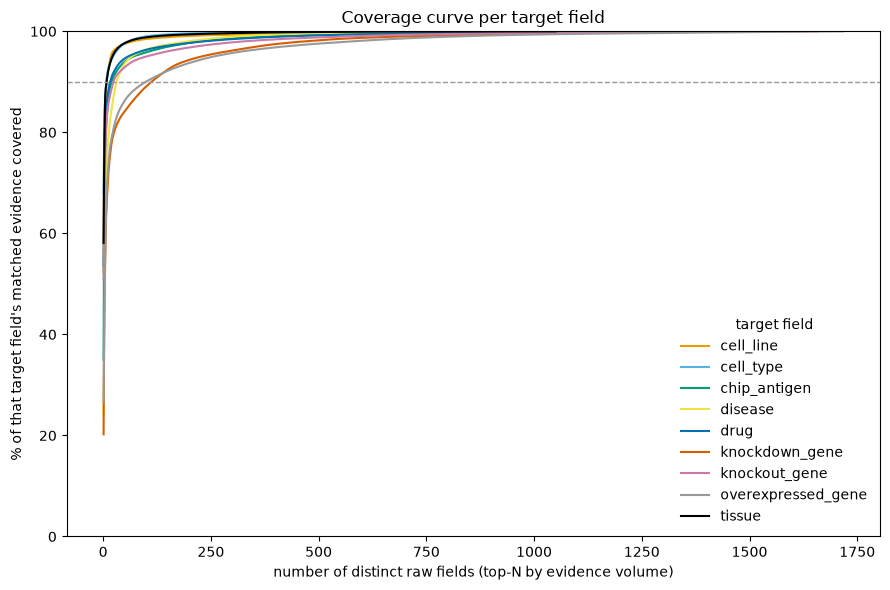

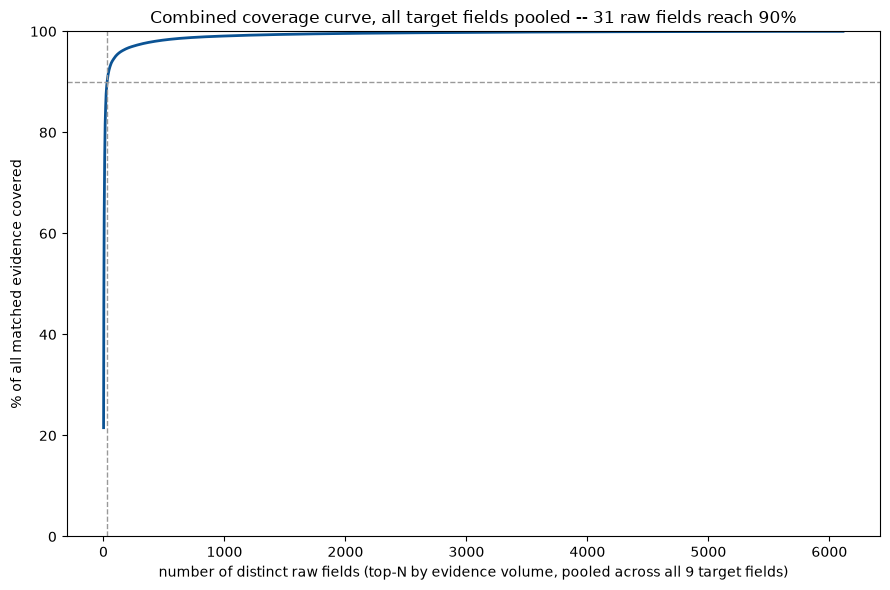

Combined across all 9 target fields, **31** distinct raw field names reach 90% coverage -- well below the **330** you'd get by adding up each target field's own 90%-threshold count, since a lot of that vocabulary (`source_name`, `title`, `description`, ...) is shared evidence across multiple target fields rather than each field needing its own distinct set.

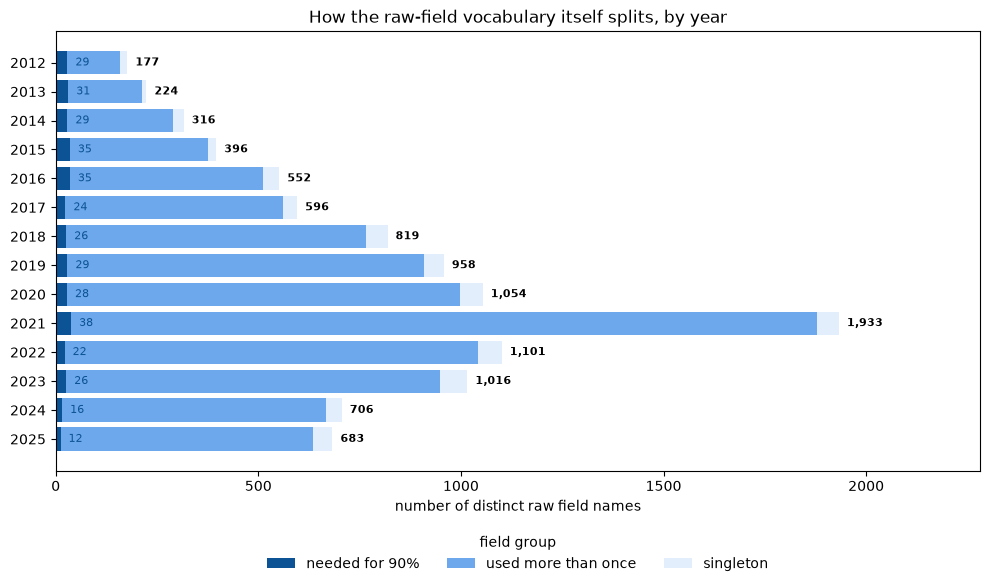

In [11]:
# COVERAGE CURVES: DISTINCT RAW FIELDS NEEDED TO REACH X% COVERAGE -- PER FIELD, POOLED, AND BY YEAR
def plot_coverage_curves_per_field(exploded: pd.DataFrame, figsize: tuple[float, float] = (9, 6)) -> None:
    fig, ax = plt.subplots(figsize=figsize)
    for target_field in TARGET_FIELDS:
        counts = exploded.loc[exploded["target_field"] == target_field, "raw_field"].value_counts()
        curve = concentration_curve(counts)
        ax.plot(curve["n_fields"], curve["pct_covered"], label=target_field, color=TARGET_FIELD_COLORS[target_field], linewidth=1.5)
    ax.axhline(90, color="#999999", linestyle="--", linewidth=1)
    ax.set_xlabel("number of distinct raw fields (top-N by evidence volume)")
    ax.set_ylabel("% of that target field's matched evidence covered")
    ax.set_title("Coverage curve per target field")
    ax.set_ylim(0, 100)
    ax.legend(title="target field", loc="lower right", frameon=False)
    plt.tight_layout()
    plt.show()


def plot_coverage_curve_pooled(exploded: pd.DataFrame, figsize: tuple[float, float] = (9, 6)) -> int:
    pooled_counts = exploded["raw_field"].value_counts()
    curve = concentration_curve(pooled_counts)
    n_for_90 = int(curve.loc[curve["pct_covered"] >= 90, "n_fields"].min())

    fig, ax = plt.subplots(figsize=figsize)
    ax.plot(curve["n_fields"], curve["pct_covered"], color="#0b5394", linewidth=2)
    ax.axhline(90, color="#999999", linestyle="--", linewidth=1)
    ax.axvline(n_for_90, color="#999999", linestyle="--", linewidth=1)
    ax.set_xlabel("number of distinct raw fields (top-N by evidence volume, pooled across all 9 target fields)")
    ax.set_ylabel("% of all matched evidence covered")
    ax.set_title(f"Combined coverage curve, all target fields pooled -- {n_for_90:,} raw fields reach 90%")
    ax.set_ylim(0, 100)
    plt.tight_layout()
    plt.show()
    return n_for_90


def plot_vocabulary_split_by_year(exploded: pd.DataFrame, figsize: tuple[float, float] = (10, 6)) -> None:
    year_exploded = exploded.dropna(subset=["year_publication"])
    year_exploded = year_exploded[year_exploded["year_publication"].between(*YEAR_RANGE)]
    years = sorted(year_exploded["year_publication"].unique())
    segments, labels = concentration_segments_by(year_exploded, "year_publication", years)
    colors = ["#0b5394", "#6da7ec", "#e3eefc"]

    fig, ax = plt.subplots(figsize=figsize)
    y_pos = range(len(years))
    left = pd.Series(0.0, index=segments.index)
    for label, color in zip(labels, colors):
        ax.barh(y_pos, segments[label], left=left, label=label, color=color)
        left += segments[label]
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels([int(year) for year in years])
    ax.invert_yaxis()  # earliest year at top
    ax.set_xlabel("number of distinct raw field names")
    ax.set_title("How the raw-field vocabulary itself splits, by year")
    ax.legend(title="field group", loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=len(labels), frameon=False)

    # same needed-for-90% / total labels as the by-target-field version above
    need_for_90 = segments[labels[0]]
    totals = segments.sum(axis=1)
    ax.set_xlim(0, totals.max() * 1.18)
    for y, year in zip(y_pos, years):
        ax.text(need_for_90[year], y, f"  {int(need_for_90[year]):,}", va="center", ha="left", fontsize=8, color=colors[0])
        ax.text(totals[year], y, f"  {int(totals[year]):,}", va="center", ha="left", fontsize=8, color="black", fontweight="bold")
    plt.tight_layout()
    plt.show()


plot_coverage_curves_per_field(exploded)
n_pooled_for_90 = plot_coverage_curve_pooled(exploded)
per_field_needed, per_field_labels = field_count_segments(exploded)
sum_per_field_90 = int(per_field_needed[per_field_labels[0]].sum())
md(
    f"Combined across all 9 target fields, **{n_pooled_for_90:,}** distinct raw field names reach 90% coverage -- "
    f"well below the **{sum_per_field_90:,}** you'd get by adding up each target field's own 90%-threshold count, "
    "since a lot of that vocabulary (`source_name`, `title`, `description`, ...) is shared evidence across multiple target fields rather than each field needing its own distinct set."
)
plot_vocabulary_split_by_year(exploded)

## Where the evidence comes from: the target field itself, another structured field, or free text

Each evidence match is classified by where in the record it was found: in the target field itself, in a different structured attribute, or in a free-text field. This section compares that mix across target fields and shows how it changes over time.

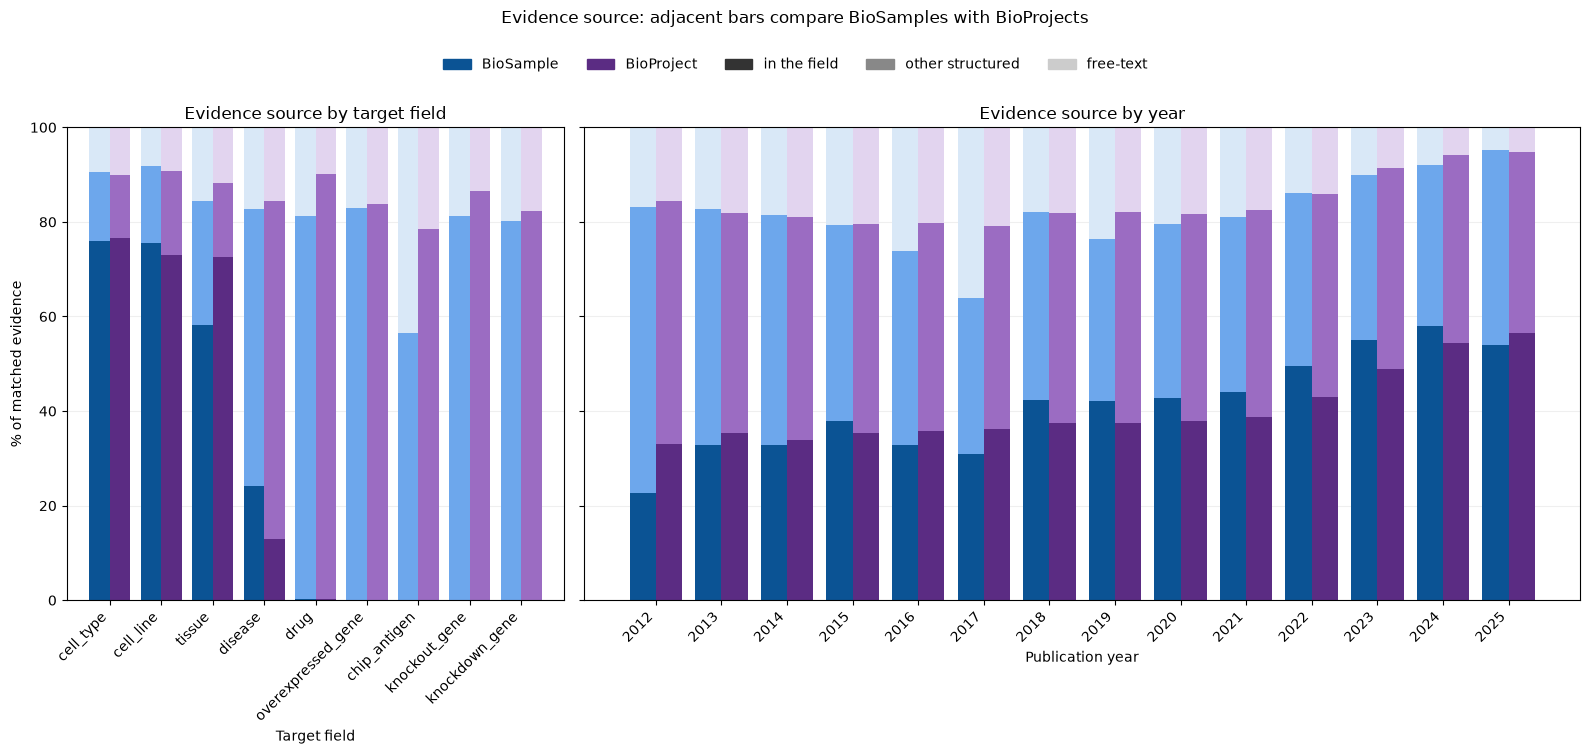

In [12]:
# EVIDENCE SOURCE: ADJACENT BIOSAMPLE/BIOPROJECT BARS, BY FIELD AND YEAR
EVIDENCE_SOURCE_ORDER = ["in the field", "other structured", "free-text"]
LEVEL_COLORS = {
    "BioSample": ["#0b5394", "#6da7ec", "#d9e8f7"],
    "BioProject": ["#5b2c83", "#9b6cc2", "#e2d4ef"],
}
SOURCE_LEGEND_COLORS = ["#333333", "#888888", "#cccccc"]


def classify_evidence_source(exploded: pd.DataFrame) -> pd.Series:
    target_norm = exploded["target_field"].map(normalize_field_name)
    in_field = exploded["raw_field_norm"] == target_norm
    return pd.Series(
        np.select([in_field, exploded["is_free_text"]], ["in the field", "free-text"], default="other structured"),
        index=exploded.index,
    )


exploded["evidence_source"] = classify_evidence_source(exploded)


def evidence_source_percentages(evidence: pd.DataFrame, group_columns: list[str]) -> pd.DataFrame:
    counts = evidence.groupby([*group_columns, "evidence_source"]).size().unstack(fill_value=0)
    counts = counts.reindex(columns=EVIDENCE_SOURCE_ORDER, fill_value=0)
    return 100 * counts.div(counts.sum(axis=1), axis=0)


def evidence_source_over_time(evidence: pd.DataFrame, date_col: str = "year_publication") -> pd.DataFrame:
    subset = evidence.dropna(subset=[date_col])
    subset = subset[subset[date_col].between(*YEAR_RANGE)]
    counts = subset.groupby([date_col, "evidence_source"]).size().unstack(fill_value=0)
    return (100 * counts.div(counts.sum(axis=1), axis=0)).reindex(columns=EVIDENCE_SOURCE_ORDER, fill_value=0)


def plot_evidence_source_levels(exploded: pd.DataFrame, figsize: tuple[float, float] = (16, 7)) -> None:
    bioproject_field = exploded.dropna(subset=["bioproject_id"]).drop_duplicates(
        ["bioproject_id", "target_field", "raw_field", "evidence_source"]
    )
    bioproject_year = exploded.dropna(subset=["bioproject_id", "year_publication"]).drop_duplicates(
        ["bioproject_id", "year_publication", "target_field", "raw_field", "evidence_source"]
    )
    field_data = [("BioSample", exploded), ("BioProject", bioproject_field)]
    year_data = [("BioSample", exploded), ("BioProject", bioproject_year)]

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True, gridspec_kw={"width_ratios": [1, 2]})
    for ax, data, group_column, xlabel, title in [
        (axes[0], field_data, "target_field", "Target field", "Evidence source by target field"),
        (axes[1], year_data, "year_publication", "Publication year", "Evidence source by year"),
    ]:
        percentages_by_level = []
        for level_label, evidence in data:
            if group_column == "year_publication":
                percentages_by_level.append((level_label, evidence_source_over_time(evidence)))
            else:
                percentages_by_level.append((level_label, evidence_source_percentages(evidence, [group_column])))
        if group_column == "target_field":
            biosample_percentages = percentages_by_level[0][1]
            categories = sorted(
                biosample_percentages.index,
                key=lambda category: (
                    biosample_percentages.loc[category, "in the field"],
                    biosample_percentages.loc[category, "other structured"],
                ),
                reverse=True,
            )
        else:
            categories = sorted(set().union(*(percentages.index for _, percentages in percentages_by_level)))
        for category_index, category in enumerate(categories):
            group_start = category_index * 2.5
            for bar_position, (level_label, percentages) in zip([group_start, group_start + 1], percentages_by_level):
                row = percentages.reindex([category]).fillna(0)
                bottom = 0.0
                for source, color in zip(EVIDENCE_SOURCE_ORDER, LEVEL_COLORS[level_label]):
                    value = row[source].iloc[0]
                    ax.bar(bar_position, value, bottom=bottom, width=1.0, color=color)
                    bottom += value

        ax.set_xticks([index * 2.5 + 0.5 for index in range(len(categories))], categories, rotation=45, ha="right")
        ax.set_xlabel(xlabel)
        ax.set_ylim(0, 100)
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.2)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("% of matched evidence")
    level_handles = [
        plt.Rectangle((0, 0), 1, 1, color=LEVEL_COLORS[level][0], label=level)
        for level in ["BioSample", "BioProject"]
    ]
    source_handles = [
        plt.Rectangle((0, 0), 1, 1, color=color, label=source)
        for source, color in zip(EVIDENCE_SOURCE_ORDER, SOURCE_LEGEND_COLORS)
    ]
    fig.legend(handles=level_handles + source_handles, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.02), frameon=False)
    fig.suptitle("Evidence source: adjacent bars compare BioSamples with BioProjects", y=1.07)
    plt.tight_layout()
    plt.show()


plot_evidence_source_levels(exploded)

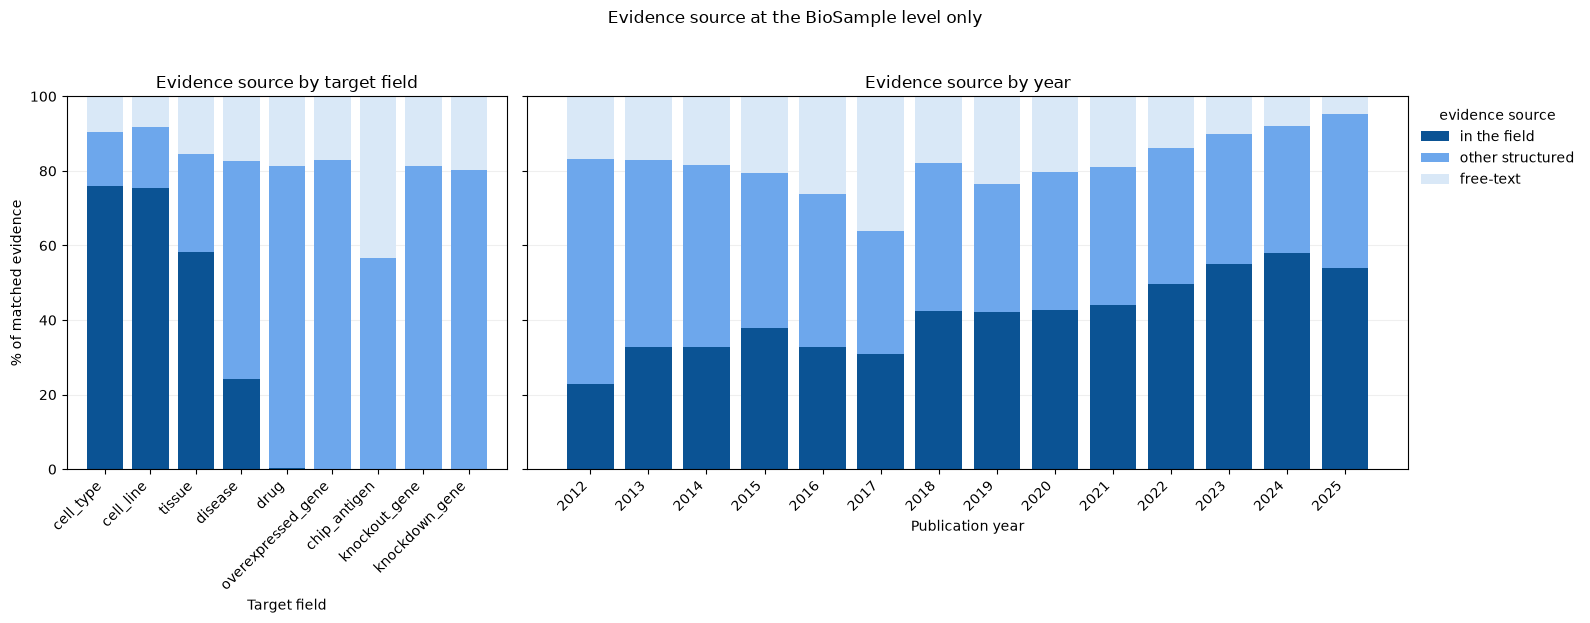

In [13]:
# EVIDENCE SOURCE AT THE BIOSAMPLE LEVEL ONLY -- SAME TWO PANELS, WITHOUT THE BIOPROJECT COMPARISON
def plot_evidence_source_biosample_only(exploded: pd.DataFrame, figsize: tuple[float, float] = (16, 6)) -> None:
    field_percentages = evidence_source_percentages(exploded, ["target_field"])
    year_percentages = evidence_source_over_time(exploded)

    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True, gridspec_kw={"width_ratios": [1, 2]})
    for ax, percentages, xlabel, title, sort_categories in [
        (axes[0], field_percentages, "Target field", "Evidence source by target field", True),
        (axes[1], year_percentages, "Publication year", "Evidence source by year", False),
    ]:
        if sort_categories:
            categories = sorted(
                percentages.index,
                key=lambda category: (percentages.loc[category, "in the field"], percentages.loc[category, "other structured"]),
                reverse=True,
            )
        else:
            categories = list(percentages.index)
        values_by_source = percentages.reindex(categories).fillna(0)
        bottom = np.zeros(len(categories))
        for source, color in zip(EVIDENCE_SOURCE_ORDER, LEVEL_COLORS["BioSample"]):
            ax.bar(range(len(categories)), values_by_source[source].to_numpy(), bottom=bottom, width=0.8, color=color, label=source)
            bottom += values_by_source[source].to_numpy()
        ax.set_xticks(range(len(categories)), categories, rotation=45, ha="right")
        ax.set_xlabel(xlabel)
        ax.set_ylim(0, 100)
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.2)
        ax.set_axisbelow(True)

    axes[0].set_ylabel("% of matched evidence")
    axes[1].legend(title="evidence source", loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False)
    fig.suptitle("Evidence source at the BioSample level only", y=1.03)
    plt.tight_layout()
    plt.show()


plot_evidence_source_biosample_only(exploded)

The free-text share is not a simple decline: it RISES from 2012 to a peak around 2017, then falls steadily and substantially through 2025 -- growing "in the field" and "other structured" share correspondingly.

The post-2017 decline (the larger, more sustained part of the pattern) lines up plausibly -- not provably from this data alone -- with the broader push toward structured, checklist-driven metadata submission over the last decade: NCBI/DDBJ's harmonized-attribute BioSample packages, MIxS/MIAME-style minimum-information checklists, and journal/funder data-sharing mandates requiring structured sample metadata have all become more consistently enforced industry-wide since roughly the late 2010s.

The pre-2017 rise doesn't fit that story as neatly, and could instead reflect which submitters/BioProjects happened to dominate the crate's earlier years rather than a field-wide behavior change -- confirming either direction would need comparing against actual standards-rollout dates and per-submitter breakdowns, which is out of scope here.

The pooled year-trend charts further below (rarefied unique raw-field count) show a similar late-decline shape -- diversity rising to a peak around 2020-2021 then falling through 2025 -- consistent with the same recent-years story.

## Why isn't every record linked to a BioProject?

BioProject linkage matters because the same raw field can dominate very differently depending on whether you count by BioSample (a BioProject with many samples counts many times) or by BioProject (each contributes once per field it uses, however many samples it has) -- but that link isn't in the raw crate for every record. This isn't a gap in this pipeline's parsing -- inspecting the raw JSON directly confirms the link is genuinely absent from the record itself, for three distinct reasons tied to *where* the record originally came from (its accession prefix):
- **EBI/ENA-origin records** (`SAMEA`, often imported via ArrayExpress) use ENA's own "Study" concept instead of NCBI's BioProject system, and carry no `Links.Link` entry with `target: "bioproject"` in this schema at all -- there is nothing to find here, in this record or any API built on this same schema.
- **Old NCBI records** (`SAMN`, mostly pre-2011/2012) predate NCBI's BioProject umbrella becoming mandatory -- their `Attributes` block is often simply `null`, with no `Links` section either.
- **Some DDBJ records** (`SAMD`) were submitted with only a bare SRA/DRA run link and no explicit BioProject attribute or link.

The origin-archive split below explains the gap far better than a per-category breakdown does.

In [14]:
# BIOPROJECT LINKAGE COVERAGE, BY CATEGORY AND ORIGIN ARCHIVE -- AS TEXT, NOT TABLES
coverage_by_category = 100 * exploded.groupby("category")["bioproject_id"].apply(lambda s: s.notna().mean())
md(
    "**BioProject linkage coverage** (share of matched-evidence rows with a resolvable primary BioProject), by category: "
    + ", ".join(f"**{pct:.1f}%** {category}" for category, pct in coverage_by_category.sort_values(ascending=False).items())
    + ". ChIP-Atlas records link to a BioProject far less often than DDBJ RNA-Seq ones, so ChIP-Atlas-heavy target fields' BioProject-level stats below rest on a smaller, less representative subset."
)

ORIGIN_ARCHIVE_BY_PREFIX = {"SAMN": "NCBI (SAMN)", "SAMD": "DDBJ (SAMD)", "SAME": "EBI/ENA (SAMEA)"}
exploded["origin_archive"] = exploded["accession"].str[:4].map(ORIGIN_ARCHIVE_BY_PREFIX)
coverage_by_origin = 100 * exploded.groupby("origin_archive")["bioproject_id"].apply(lambda s: s.notna().mean())

by_accession = exploded.drop_duplicates("accession")[["accession", "bioproject_id", "origin_archive"]]
missing = by_accession[by_accession["bioproject_id"].isna()]
missing_by_origin = missing["origin_archive"].value_counts()

md(
    "...and by origin archive (accession prefix), the real driver of the gap: "
    + ", ".join(f"**{pct:.1f}%** {origin}" for origin, pct in coverage_by_origin.sort_values(ascending=False).items())
    + f". Across the **{len(by_accession):,}** distinct BioSamples with at least one traced-back evidence value, **{len(missing):,}** "
    f"({100 * len(missing) / len(by_accession):.1f}%) have no resolvable BioProject: "
    f"**{missing_by_origin.get('EBI/ENA (SAMEA)', 0):,}** are EBI/ENA-origin (100% of that origin, by construction -- see above), "
    f"**{missing_by_origin.get('NCBI (SAMN)', 0):,}** are NCBI records (mostly pre-BioProject-era), "
    f"and **{missing_by_origin.get('DDBJ (SAMD)', 0):,}** are DDBJ records submitted without one."
)

**BioProject linkage coverage** (share of matched-evidence rows with a resolvable primary BioProject), by category: **90.0%** ChIP-Atlas, **78.4%** DDBJ RNA-Seq. ChIP-Atlas records link to a BioProject far less often than DDBJ RNA-Seq ones, so ChIP-Atlas-heavy target fields' BioProject-level stats below rest on a smaller, less representative subset.

...and by origin archive (accession prefix), the real driver of the gap: **91.8%** NCBI (SAMN), **52.9%** DDBJ (SAMD), **0.0%** EBI/ENA (SAMEA). Across the **3,946,838** distinct BioSamples with at least one traced-back evidence value, **638,334** (16.2%) have no resolvable BioProject: **323,746** are EBI/ENA-origin (100% of that origin, by construction -- see above), **294,263** are NCBI records (mostly pre-BioProject-era), and **20,325** are DDBJ records submitted without one.

**Could the missing ones be backfilled through an API?** Partially, and not cheaply. For NCBI (`SAMN`) and DDBJ (`SAMD`) records, NCBI's E-utilities and DDBJ's own REST API can look up an accession's linked BioProject -- and both support batched lookups (NCBI's `efetch`/`esummary` accept up to ~200 accessions per request), so the real bottleneck is API rate limits, not the number of records: hundreds of thousands of missing `SAMN`/`SAMD` accessions would mean thousands of batched requests, likely hours of wall-clock time at NCBI's default (unauthenticated) rate limit. Even then, a real fraction of the missing `SAMN` records are simply from before BioProject existed as a concept -- there is no BioProject to find for them, at any API. For EBI/ENA (`SAMEA`) records, this would need an entirely different API and a different target concept (ENA's "Study" accession, not a BioProject) -- a separate piece of work, not an extension of the same lookup. So a full backfill is a multi-archive engineering effort with a lower ceiling than 100%, not a one-line API call.

## How does raw-field-name diversity vary by year?

Two different, genuinely different dates are available per BioSample: `submission_date` (when the record was first submitted, not always present) and `publication_date` (when it became public, always present). Checked directly below: how often each is missing, and -- for records with both -- how much they actually differ, to decide whether using one instead of the other would materially change a year-based analysis.

In [15]:
# MISSING RATES FOR EACH DATE FIELD
md(
    f"`submission_date` missing for **{100 * metadata['submission_date'].isna().mean():.2f}%** of accessions; "
    f"`publication_date` missing for **{100 * metadata['publication_date'].isna().mean():.2f}%**."
)

`submission_date` missing for **1.02%** of accessions; `publication_date` missing for **0.00%**.

In [16]:
# HOW MUCH DO submission_date AND publication_date DISAGREE, WHERE BOTH EXIST
both_dates = metadata.dropna(subset=["submission_date", "publication_date"]).copy()
both_dates["submission_dt"] = pd.to_datetime(both_dates["submission_date"], format="mixed", utc=True, errors="coerce")
both_dates["publication_dt"] = pd.to_datetime(both_dates["publication_date"], format="mixed", utc=True, errors="coerce")
both_dates = both_dates.dropna(subset=["submission_dt", "publication_dt"])
diff_days = (both_dates["publication_dt"] - both_dates["submission_dt"]).dt.total_seconds() / 86400
n_negative = (diff_days < 0).sum()

md(
    f"Among **{len(both_dates):,}** accessions with both dates, the gap between them (`publication_date - submission_date`): "
    f"median **{diff_days.median():.0f} days**, mean **{diff_days.mean():.0f} days**, "
    f"min **{diff_days.min():,.0f} days**, max **{diff_days.max():,.0f} days**. "
    f"The mean sitting more than double the median, and **{n_negative:,}** records ({100 * n_negative / len(both_dates):.1f}%) showing a NEGATIVE gap -- published before their recorded submission date, up to {abs(diff_days.min()) / 365.25:.0f} years earlier at the extreme -- "
    "suggests `submission_date` isn't always the record's true original submission: for records re-registered or imported into this system later, it likely reflects that later event, while `publication_date` keeps the original archive-of-origin's first-public date. "
    f"Only **{100 * (both_dates['submission_dt'].dt.year == both_dates['publication_dt'].dt.year).mean():.1f}%** "
    f"share the same calendar year, and **{100 * (diff_days.abs() <= 90).mean():.1f}%** are within 90 days. "
    "The two dates diverge enough, for a large enough share of records, that a year-based trend could plausibly look different depending on which is used -- so both are shown separately below, not collapsed into one."
)

Among **4,144,993** accessions with both dates, the gap between them (`publication_date - submission_date`): median **96 days**, mean **220 days**, min **-4,448 days**, max **5,671 days**. The mean sitting more than double the median, and **627,894** records (15.1%) showing a NEGATIVE gap -- published before their recorded submission date, up to 12 years earlier at the extreme -- suggests `submission_date` isn't always the record's true original submission: for records re-registered or imported into this system later, it likely reflects that later event, while `publication_date` keeps the original archive-of-origin's first-public date. Only **59.1%** share the same calendar year, and **48.8%** are within 90 days. The two dates diverge enough, for a large enough share of records, that a year-based trend could plausibly look different depending on which is used -- so both are shown separately below, not collapsed into one.

**Controlling for how many biosamples/BioProjects exist per year.** A year with more biosamples mechanically has more unique raw field names, even with no real change in naming behavior. Every year-trend chart below uses **rarefaction** (from ecological species-richness estimation): each year is repeatedly subsampled down to the same number of units (biosamples, or BioProjects for the BioProject-level charts -- whichever is the smaller across years) before counting unique raw field names, averaged over resamples, so the comparison isn't just tracking how much data exists for that year.

One combined figure below, 4 rows (biosample x submission_date, biosample x publication_date, BioProject x submission_date, BioProject x publication_date) x 2 columns: left is a trend line per target field (do individual fields move differently over time?), right is a pooled bar chart of the raw unique-field count (does the pooled trend match what the per-field lines suggest?).

Restricted to 2012-2025: earlier years have too few records for a stable rarefied estimate, and 2026 is only partially elapsed as of this notebook's run.

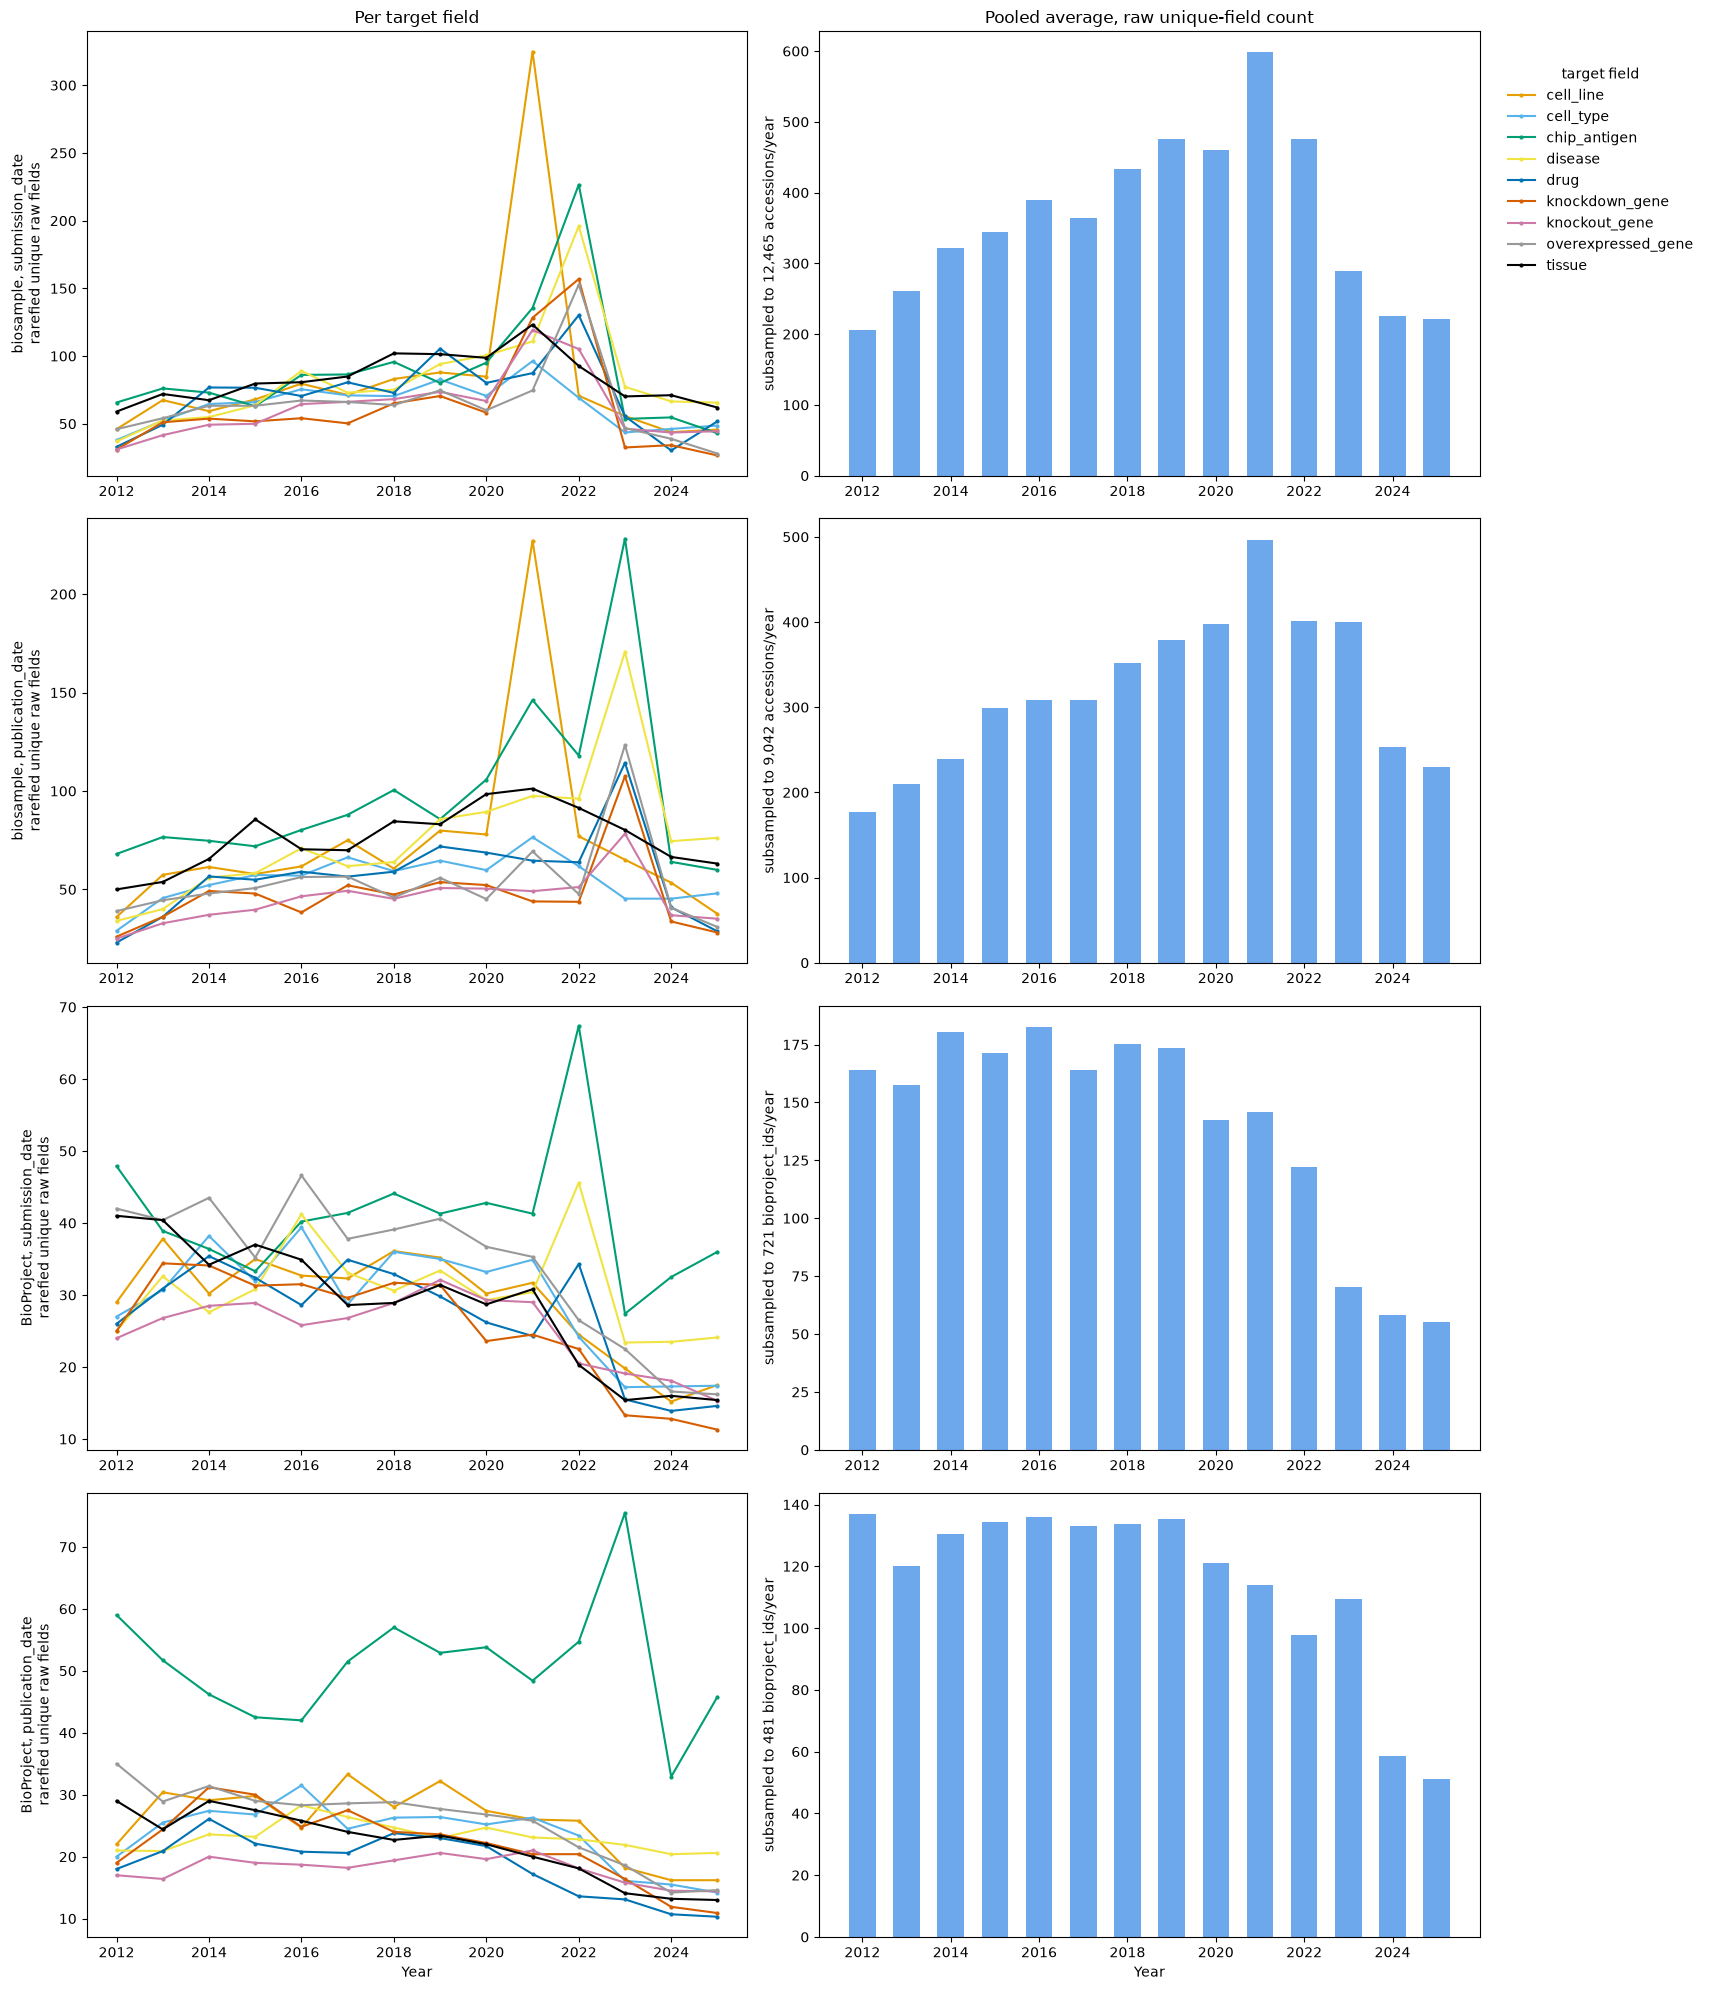

In [17]:
# RAREFIED UNIQUE RAW-FIELD COUNT PER YEAR: ALL 4 LEVEL x DATE COMBOS IN ONE 4-ROW x 2-COLUMN FIGURE
YEAR_DIVERSITY_COMBOS = [
    ("year_submission", "accession", "biosample", "submission_date"),
    ("year_publication", "accession", "biosample", "publication_date"),
    ("year_submission", "bioproject_id", "BioProject", "submission_date"),
    ("year_publication", "bioproject_id", "BioProject", "publication_date"),
]


def plot_year_diversity_grid(exploded: pd.DataFrame, figsize: tuple[float, float] = (15, 20)) -> None:
    fig, axes = plt.subplots(len(YEAR_DIVERSITY_COMBOS), 2, figsize=figsize)

    for row, (date_col, unit_col, level_label, date_label) in enumerate(YEAR_DIVERSITY_COMBOS):
        ax_trend, ax_avg = axes[row]

        # slim to just the columns this combo needs before any filtering -- filtering the full
        # ~20-column exploded frame repeatedly (9 fields + 1 pooled, per combo) was the actual
        # bottleneck, copying columns (raw_texts, assigned_term_synonyms, ...) never used here
        combo_cols = ["target_field", date_col, unit_col, "raw_field"]
        combo_base = exploded[combo_cols].dropna(subset=[date_col, unit_col])
        combo_base = combo_base[combo_base[date_col].between(*YEAR_RANGE)]

        # left: trend line per target field
        for target_field in TARGET_FIELDS:
            sub = combo_base[combo_base["target_field"] == target_field]
            res = rarefied_unique_counts(sub, date_col, unit_col, "raw_field", n_iter=N_RAREFACTION_ITER)
            ax_trend.plot(res[date_col], res["mean_unique"], label=target_field, color=TARGET_FIELD_COLORS[target_field], linewidth=1.5, marker="o", markersize=2)
        ax_trend.set_ylabel(f"{level_label}, {date_label}\nrarefied unique raw fields")

        # right: pooled average, raw unique-field count
        raw_res = rarefied_unique_counts(combo_base, date_col, unit_col, "raw_field", n_iter=N_RAREFACTION_ITER)
        ax_avg.bar(raw_res[date_col], raw_res["mean_unique"], width=0.6, color="#6da7ec")
        ax_avg.set_ylabel(f"subsampled to {int(raw_res['k'].iloc[0]):,} {unit_col}s/year")

        if row == 0:
            ax_trend.set_title("Per target field")
            ax_avg.set_title("Pooled average, raw unique-field count")
        if row == len(YEAR_DIVERSITY_COMBOS) - 1:
            ax_trend.set_xlabel("Year")
            ax_avg.set_xlabel("Year")

    field_handles, field_labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(field_handles, field_labels, title="target field", loc="upper left", bbox_to_anchor=(1.0, 0.97), frameon=False)
    plt.tight_layout()
    plt.show()


plot_year_diversity_grid(exploded)

### What does the raw (non-rarefied) growth curve look like?

Rarefaction above deliberately removes the effect of "more data this year"; this section restores it, to see the field vocabulary's actual, uncorrected growth. Restricted to BioSample x `publication_date` (always present, unlike `submission_date` -- see above) to keep this to one representative view rather than repeating all 4 level x date combos, and to the **DDBJ RNA-Seq** category only (dropping ChIP-Atlas), so the trend reflects one submission pipeline rather than mixing two with different histories and generalizes better. Two groups of two: the top row is each year's own count (per target field, then averaged across fields); the bottom row is the cumulative, ever-seen-by-that-year count, to check whether the vocabulary plateaus or keeps growing. Both "average across target fields" panels also plot the number of BioProjects published that year (orange line, right axis) alongside the blue bar, to check whether diversity growth just tracks how many BioProjects exist that year. The yearly average bar is split three ways: raw field names also seen in other years (dark blue), names used only in that single year but more than once (medium blue), and true singletons -- names used in exactly one evidence row ever, across the whole 2012-2025 range (lightest blue, a subset of the "unique to that year" group). The cumulative average bar gets the same lightest-blue treatment: of the raw fields ever seen by a given year, how many are those same true singletons -- so both rows show how much of the vocabulary's apparent size is one-off names that never recur, rather than a real, reusable naming convention.

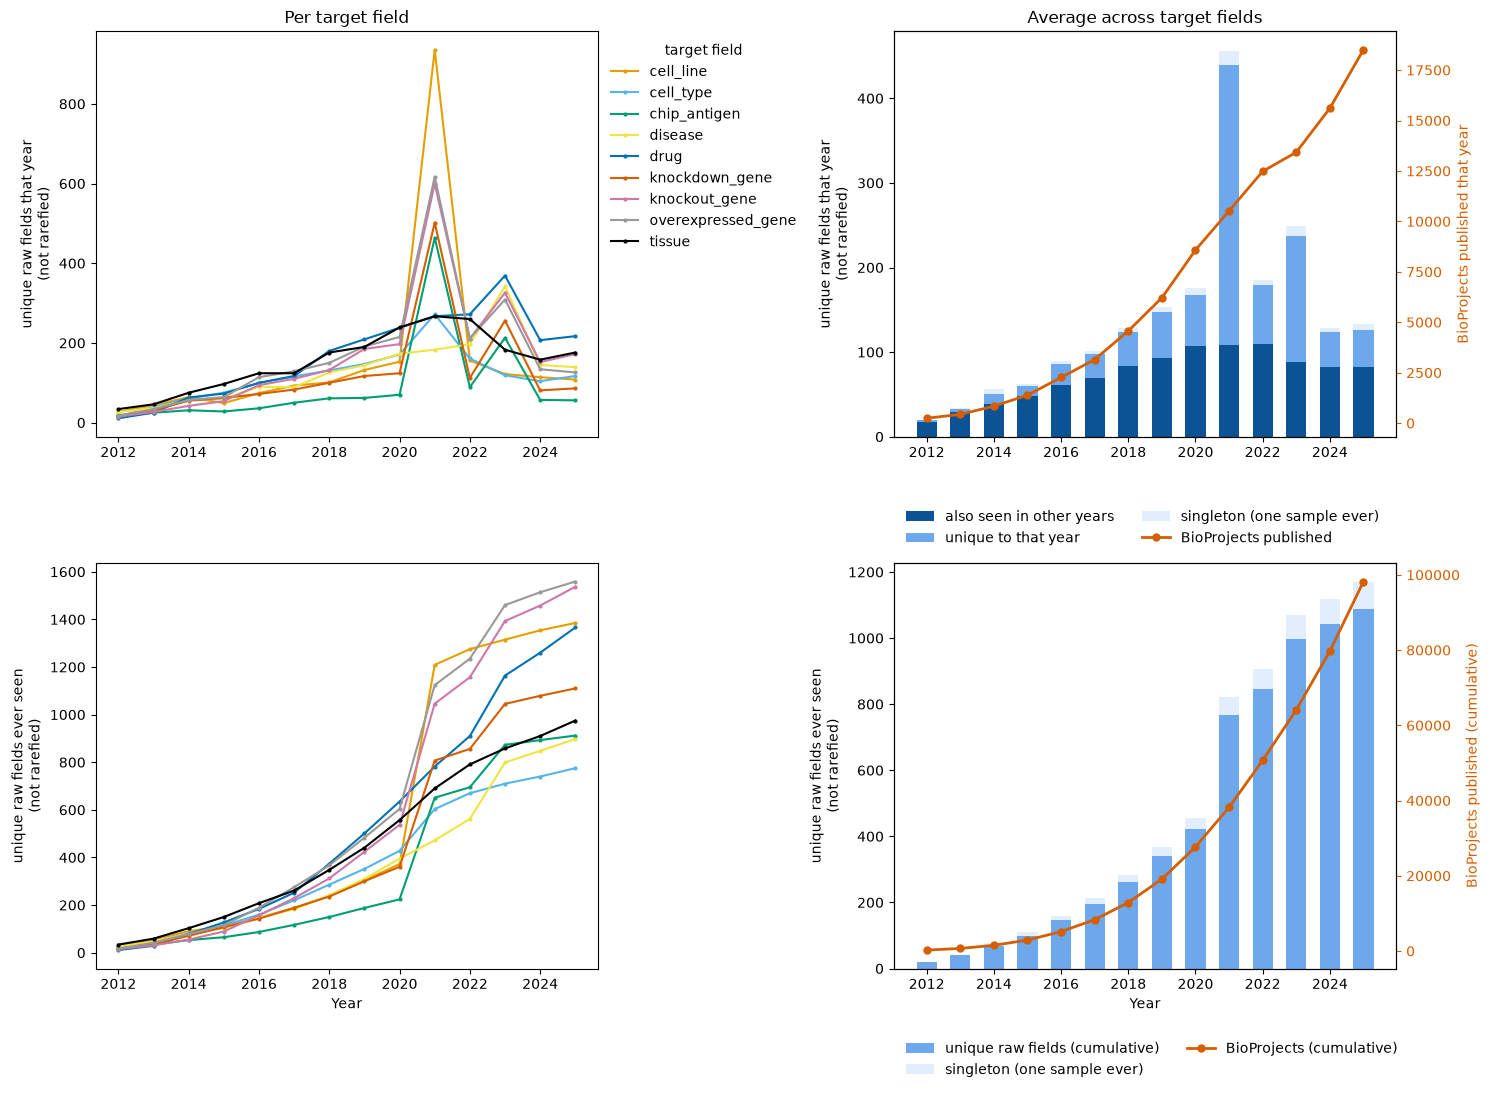

In [18]:
# NON-RAREFIED YEARLY AND CUMULATIVE UNIQUE-RAW-FIELD COUNTS, DDBJ RNA-SEQ BIOSAMPLES x publication_date
rnaseq_exploded = exploded[exploded["category"] == "DDBJ RNA-Seq"]


def yearly_unique_field_counts(exploded: pd.DataFrame, date_col: str) -> pd.DataFrame:
    """Per target field, per year: how many distinct raw field names appeared (`n_unique`), how
    many of those are used in that single year only, nowhere else across the whole range
    (`n_exclusive`), and how many are true singletons -- used in exactly one evidence row ever,
    across every year (`n_singleton`, a subset of `n_exclusive`). Feeds the 3-way stacked "unique
    raw fields that year" bar below.
    """
    subset = exploded.dropna(subset=[date_col])
    subset = subset[subset[date_col].between(*YEAR_RANGE)]
    rows = []
    for target_field in TARGET_FIELDS:
        field_subset = subset[subset["target_field"] == target_field]
        years_per_name = field_subset.groupby("raw_field")[date_col].nunique()
        exclusive_names = set(years_per_name[years_per_name == 1].index)
        total_counts = field_subset["raw_field"].value_counts()
        singleton_names = set(total_counts[total_counts == 1].index)
        for year, year_group in field_subset.groupby(date_col):
            names_that_year = set(year_group["raw_field"].unique())
            rows.append(
                {
                    "target_field": target_field,
                    date_col: year,
                    "n_unique": len(names_that_year),
                    "n_exclusive": len(names_that_year & exclusive_names),
                    "n_singleton": len(names_that_year & singleton_names),
                }
            )
    return pd.DataFrame(rows)


def cumulative_unique_field_counts(exploded: pd.DataFrame, date_col: str, years: list[int]) -> pd.DataFrame:
    """Running union of raw field names seen in each target field up to and including each year
    (`n_unique_cumulative`), plus how many of those are true singletons -- names used in exactly
    one evidence row across the whole range, wherever their one occurrence falls
    (`n_singleton_cumulative`, a subset of `n_unique_cumulative`) -- to check whether the
    vocabulary plateaus over time, and how much of its growth is one-off names that never recur.
    """
    rows = []
    for target_field in TARGET_FIELDS:
        sub = exploded[(exploded["target_field"] == target_field) & exploded[date_col].between(*YEAR_RANGE)]
        total_counts = sub["raw_field"].value_counts()
        singleton_names = set(total_counts[total_counts == 1].index)
        seen: set[str] = set()
        seen_singleton: set[str] = set()
        for year in years:
            year_names = set(sub.loc[sub[date_col] == year, "raw_field"])
            seen |= year_names
            seen_singleton |= year_names & singleton_names
            rows.append(
                {
                    "target_field": target_field,
                    date_col: year,
                    "n_unique_cumulative": len(seen),
                    "n_singleton_cumulative": len(seen_singleton),
                }
            )
    return pd.DataFrame(rows)


def bioproject_year_counts(exploded: pd.DataFrame, date_col: str) -> pd.DataFrame:
    """Distinct BioProjects per year (keyed by the EARLIEST evidence-row date seen for that
    BioProject) plus the running cumulative total -- a secondary series to check whether
    raw-field-diversity growth just tracks how many BioProjects exist, rather than reflecting a
    real change in naming behavior.
    """
    bioproject_dates = exploded.dropna(subset=["bioproject_id", date_col]).groupby("bioproject_id")[date_col].min()
    bioproject_dates = bioproject_dates[bioproject_dates.between(*YEAR_RANGE)]
    yearly = bioproject_dates.value_counts().sort_index()
    return pd.DataFrame({date_col: yearly.index, "n_bioprojects": yearly.to_numpy(), "n_bioprojects_cumulative": yearly.cumsum().to_numpy()})


def plot_year_growth_grid(exploded: pd.DataFrame, date_col: str = "year_publication", figsize: tuple[float, float] = (15, 11)) -> None:
    yearly = yearly_unique_field_counts(exploded, date_col)
    years = sorted(yearly[date_col].unique())
    cumulative = cumulative_unique_field_counts(exploded, date_col, years)
    bioprojects = bioproject_year_counts(exploded, date_col).set_index(date_col)

    fig, ((ax_yearly_field, ax_yearly_avg), (ax_cum_field, ax_cum_avg)) = plt.subplots(2, 2, figsize=figsize)

    for target_field in TARGET_FIELDS:
        field_yearly = yearly[yearly["target_field"] == target_field]
        ax_yearly_field.plot(field_yearly[date_col], field_yearly["n_unique"], label=target_field, color=TARGET_FIELD_COLORS[target_field], linewidth=1.5, marker="o", markersize=2)
        field_cum = cumulative[cumulative["target_field"] == target_field]
        ax_cum_field.plot(field_cum[date_col], field_cum["n_unique_cumulative"], label=target_field, color=TARGET_FIELD_COLORS[target_field], linewidth=1.5, marker="o", markersize=2)

    # yearly average, stacked 3 ways: recurring across years, unique-to-that-year (multiple samples), true singletons (one sample ever)
    yearly_avg = yearly.groupby(date_col)[["n_unique", "n_exclusive", "n_singleton"]].mean()
    recurring_avg = yearly_avg["n_unique"] - yearly_avg["n_exclusive"]
    exclusive_multi_avg = yearly_avg["n_exclusive"] - yearly_avg["n_singleton"]
    singleton_avg = yearly_avg["n_singleton"]
    years_arr = yearly_avg.index.to_numpy()
    ax_yearly_avg.bar(years_arr, recurring_avg, width=0.6, color="#0b5394", label="also seen in other years")
    ax_yearly_avg.bar(years_arr, exclusive_multi_avg, width=0.6, bottom=recurring_avg, color="#6da7ec", label="unique to that year")
    ax_yearly_avg.bar(years_arr, singleton_avg, width=0.6, bottom=recurring_avg + exclusive_multi_avg, color="#e3eefc", label="singleton (one sample ever)")

    # cumulative average, stacked 2 ways: recurring (seen more than once, ever) + true singletons
    cum_avg = cumulative.groupby(date_col)[["n_unique_cumulative", "n_singleton_cumulative"]].mean()
    cum_recurring_avg = cum_avg["n_unique_cumulative"] - cum_avg["n_singleton_cumulative"]
    cum_singleton_avg = cum_avg["n_singleton_cumulative"]
    cum_years_arr = cum_avg.index.to_numpy()
    ax_cum_avg.bar(cum_years_arr, cum_recurring_avg, width=0.6, color="#6da7ec", label="unique raw fields (cumulative)")
    ax_cum_avg.bar(cum_years_arr, cum_singleton_avg, width=0.6, bottom=cum_recurring_avg, color="#e3eefc", label="singleton (one sample ever)")

    # BioProjects published, as a line on a second y-axis rather than a second bar -- reads more
    # cleanly than two adjacent bar series at very different scales
    ax_yearly_bp = ax_yearly_avg.twinx()
    ax_yearly_bp.plot(years_arr, bioprojects.reindex(years_arr)["n_bioprojects"], color="#d55e00", linewidth=2, marker="o", markersize=5, label="BioProjects published")
    ax_yearly_bp.set_ylabel("BioProjects published that year", color="#d55e00")
    ax_yearly_bp.tick_params(axis="y", colors="#d55e00")

    ax_cum_bp = ax_cum_avg.twinx()
    ax_cum_bp.plot(cum_years_arr, bioprojects.reindex(cum_years_arr)["n_bioprojects_cumulative"], color="#d55e00", linewidth=2, marker="o", markersize=5, label="BioProjects (cumulative)")
    ax_cum_bp.set_ylabel("BioProjects published (cumulative)", color="#d55e00")
    ax_cum_bp.tick_params(axis="y", colors="#d55e00")

    ax_yearly_field.set_title("Per target field")
    ax_yearly_avg.set_title("Average across target fields")
    ax_yearly_field.set_ylabel("unique raw fields that year\n(not rarefied)")
    ax_yearly_avg.set_ylabel("unique raw fields that year\n(not rarefied)")
    ax_cum_field.set_ylabel("unique raw fields ever seen\n(not rarefied)")
    ax_cum_avg.set_ylabel("unique raw fields ever seen\n(not rarefied)")
    ax_cum_field.set_xlabel("Year")
    ax_cum_avg.set_xlabel("Year")
    ax_yearly_field.legend(title="target field", loc="upper left", bbox_to_anchor=(1.0, 1.0), frameon=False)

    yearly_handles, yearly_labels = ax_yearly_avg.get_legend_handles_labels()
    yearly_bp_handles, yearly_bp_labels = ax_yearly_bp.get_legend_handles_labels()
    ax_yearly_avg.legend(yearly_handles + yearly_bp_handles, yearly_labels + yearly_bp_labels, loc="upper left", bbox_to_anchor=(0.0, -0.15), frameon=False, ncol=2)

    cum_handles, cum_labels = ax_cum_avg.get_legend_handles_labels()
    cum_bp_handles, cum_bp_labels = ax_cum_bp.get_legend_handles_labels()
    ax_cum_avg.legend(cum_handles + cum_bp_handles, cum_labels + cum_bp_labels, loc="upper left", bbox_to_anchor=(0.0, -0.15), frameon=False, ncol=2)

    plt.tight_layout()
    plt.show()


plot_year_growth_grid(rnaseq_exploded)

### What were the top field names unique to each year?

The light-blue segment above shows HOW MANY raw field names were unique to a given year; the table below shows WHICH ones, to investigate any year that stands out (e.g. a peak around 2021). Pooled across all 9 target fields (a name can carry evidence for more than one), ranked by the number of distinct BioProjects that used it that year -- shown alongside the % share of that year's BioSample-level evidence rows, as **P**roject / **S**ample (e.g. `tissue (32%P, 25%S)`), to see whether the two views agree on what "top" means.

In [19]:
# TOP RAW FIELD NAMES UNIQUE TO EACH YEAR, BY % SHARE OF THAT YEAR'S EVIDENCE (BIOPROJECT AND BIOSAMPLE)
def top_unique_raw_fields_per_year(exploded: pd.DataFrame, date_col: str, top_n: int = 10) -> pd.DataFrame:
    subset = exploded.dropna(subset=[date_col])
    subset = subset[subset[date_col].between(*YEAR_RANGE)]
    years_per_name = subset.groupby("raw_field")[date_col].nunique()
    exclusive_names = set(years_per_name[years_per_name == 1].index)
    subset = subset[subset["raw_field"].isin(exclusive_names)]

    rows = []
    for year, year_group in subset.groupby(date_col):
        total_rows = len(year_group)
        total_bioprojects = year_group["bioproject_id"].nunique()
        row_counts = year_group["raw_field"].value_counts()
        bioproject_counts = year_group.dropna(subset=["bioproject_id"]).groupby("raw_field")["bioproject_id"].nunique()
        top = bioproject_counts.sort_values(ascending=False).head(top_n)
        parts = []
        for field, n_bioprojects in top.items():
            pct_bioprojects = 100 * n_bioprojects / total_bioprojects if total_bioprojects else 0
            pct_rows = 100 * row_counts.get(field, 0) / total_rows if total_rows else 0
            parts.append(f"<b>{html.escape(field)}</b> ({pct_bioprojects:.0f}%P, {pct_rows:.0f}%S)")
        rows.append({"year": int(year), "n_exclusive_fields": len(row_counts), "top_unique_fields": RawHTML(", ".join(parts))})
    return pd.DataFrame(rows).sort_values("year")


unique_terms_by_year = top_unique_raw_fields_per_year(rnaseq_exploded, "year_publication")
display_with_nested_tables(unique_terms_by_year.assign(n_exclusive_fields=unique_terms_by_year["n_exclusive_fields"].map("{:,}".format)))

year,n_exclusive_fields,top_unique_fields
2012,22,"ChIP (11%P, 16%S), crosses (11%P, 2%S), antibody 1 (6%P, 1%S), antibody vendor (6%P, 1%S), antibody 2 (6%P, 3%S), breast cancer patient (6%P, 3%S), cardioglycoside treatment (6%P, 3%S), cell line stably expressing (6%P, 3%S), clinical form (6%P, 3%S), enriched spermatogenesis stage (6%P, 0%S)"
2013,31,"blood draw (6%P, 9%S), blood processed by (6%P, 14%S), camptothecin exposure time (6%P, 2%S), cell group (6%P, 1%S), cell line specificity (6%P, 1%S), chemical treatment condition (6%P, 2%S), cycloheximide (6%P, 2%S), hits-clip antibody (6%P, 1%S), iclip antibody (6%P, 2%S), ig chain (6%P, 3%S)"
2014,64,"resistant to (6%P, 1%S), Cell_origin (3%P, 1%S), Doxycycline concentration (3%P, 1%S), additional_information (3%P, 8%S), 4hr ex vivo treatment (3%P, 1%S), antibody for pull-down (3%P, 0%S), cdh1 genotype (3%P, 0%S), condition/treatment (3%P, 0%S), date of melanoma diagnosis (3%P, 1%S), doxycycline concentration (3%P, 0%S)"
2015,96,"sirs outcomes (3%P, 3%S), biomaterial (1%P, 0%S), cell characterization (1%P, 0%S), cell line used (1%P, 2%S), cell modifications (1%P, 0%S), cell stimulation (1%P, 1%S), cell synchronization (1%P, 0%S), chemical_treatement (1%P, 0%S), bcl2 (1%P, 0%S), classifications (1%P, 0%S)"
2016,158,"boost_agent (2%P, 0%S), prime_agent (2%P, 0%S), fed with (2%P, 0%S), activation ab (1%P, 0%S), agonist/conditions (1%P, 0%S), antibodystimulation (1%P, 0%S), ar expression status (1%P, 0%S), assay (1%P, 0%S), arid1a expression (1%P, 0%S), atfs (1%P, 0%S)"
2017,167,"1h pretreatment (1%P, 0%S), cell sorting strategy (1%P, 0%S), noncancer- cancer (1%P, 1%S), mutant gene (1%P, 0%S), mir122 status (1%P, 0%S), inventory sample name (1%P, 0%S), facs selection (1%P, 5%S), Files name (1%P, 0%S), 1 day treatment (1%P, 0%S), bcr-abl status (1%P, 1%S)"
2018,275,"media supplement (1%P, 0%S), ln (1%P, 0%S), lentivirus infected (1%P, 0%S), lentiviral grna (1%P, 6%S), injection site (1%P, 0%S), reprogramming time-point (1%P, 0%S), env_feature (1%P, 0%S), resident tissue (1%P, 0%S), saha dose (1%P, 0%S), sorting gate (1%P, 1%S)"
2019,361,"animal line (4%P, 1%S), organism (2%P, 1%S), infection protocol (2%P, 3%S), sort parameters (1%P, 0%S), aso (1%P, 0%S), treatment and stage (1%P, 0%S), miRNA (1%P, 0%S), transduced cdna (1%P, 0%S), representative population (1%P, 0%S), tnf-alpha treatment (1%P, 0%S)"
2020,401,"background line (1%P, 1%S), index_sort_annotation (1%P, 3%S), COD category (1%P, 0%S), organ site (1%P, 1%S), kidney region (1%P, 0%S), oncotype (1%P, 1%S), paclitaxel sensitivity (1%P, 0%S), chow (1%P, 0%S), pdx (1%P, 0%S), morphology type (1%P, 0%S)"
2021,"1,250","aud status (1%P, 0%S), gene aberrations (1%P, 0%S), pharmacological treatment (1%P, 0%S), transgenic mouse genotype (1%P, 0%S), donor organ (1%P, 0%S), severity (1%P, 0%S), blood (1%P, 0%S), genetic manipulation (1%P, 0%S), cell syngeneic orthotopic transplant (1%P, 0%S), transcription factor (1%P, 0%S)"


## Summary

- The stacked-bar recap (deterministic tiers plus the two Qwen LLM passes, one tier explained per bullet just above it) shows the trace-back check resolves the large majority of extracted values across all 9 target fields, mostly via the strongest deterministic tiers.
- A modest handful of raw field names account for most evidence for `cell_type`/`tissue`/`cell_line`; `disease`/the gene-perturbation fields need many more distinct raw fields to reach the same coverage.
- Regex normalization (case/separator collapsing) reduces the raw field-name count by a real but modest amount -- most of the diversity is genuinely different names, not spelling variants.
- Most of that diversity is a long tail of singleton, one-off field names contributing negligible evidence, and it's spread across many independent submitting labs rather than concentrated in a few.
- Missing BioProject linkage (~16% of BioSamples) is explained almost entirely by *where* a record originated (EBI/ENA-origin records structurally have none; old NCBI records predate BioProject; some DDBJ records were submitted without one) -- not a gap in this pipeline, and only partially, expensively fixable via API.
- Year-over-year naming diversity -- both rarefaction-controlled and the raw, uncontrolled growth curve -- and the evidence-source mix (in-the-field / other-structured / free-text) both show real movement over the crate's history, worth revisiting once the trace-back job reaches 100%.